# Detección de Somnolencia: Ojos Abiertos vs Cerrados
**Pipeline:** Dataset Kaggle → CNN binaria (PyTorch) → MediaPipe Face Mesh (extracción de ojos) → Detección en tiempo real con webcam → Alarma a los 5 segundos

Entorno: conda `deeplearning` (Python 3.11, PyTorch + CUDA)

Instalar dependencias (solo la primera vez):
```
pip install mediapipe opencv-python
```

In [1]:
# ============ CELDA 1: Imports y configuración ============
import os
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Ruta del dataset (ajusta si es necesario)
DATA_DIR = r"C:\Users\aaron\IOT\archive\train"
IMG_SIZE = 64          # las imágenes de ojos son pequeñas, 64x64 es suficiente
BATCH_SIZE = 64
EPOCHS = 15
SEED = 42
torch.manual_seed(SEED)

ModuleNotFoundError: No module named 'cv2'

In [2]:
# ============ CELDA 2: Cargar SOLO las clases Closed y Open ============
import os

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Subclase que SOLO reconoce Closed y Open como clases válidas.
# Cualquier otra carpeta (.ipynb_checkpoints, yawn, no_yawn) es ignorada.
class EyeFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        clases = ["Closed", "Open"]
        class_to_idx = {"Closed": 0, "Open": 1}
        return clases, class_to_idx

full_ds = EyeFolder(DATA_DIR, transform=train_tf)
print("Clases detectadas:", full_ds.classes)

idx_closed = 0   # Closed
idx_open   = 1   # Open

# Todas las muestras ya son solo Closed/Open
keep = list(range(len(full_ds.samples)))

n_closed = sum(1 for _, y in full_ds.samples if y == idx_closed)
n_open   = sum(1 for _, y in full_ds.samples if y == idx_open)
print(f"Imágenes de ojos: {len(keep)} total")
print(f"  - Cerrados (Closed): {n_closed}")
print(f"  - Abiertos (Open):   {n_open}")

# Remapeo de etiquetas (ya vienen como 0=Closed, 1=Open)
class EyesDataset(torch.utils.data.Dataset):
    def __init__(self, base, indices, transform):
        self.base = base
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, y = self.base.samples[self.indices[i]]
        img = datasets.folder.default_loader(path)
        x = self.transform(img)
        return x, y   # 0=cerrado, 1=abierto

CLASSES = ["Cerrado", "Abierto"]

Clases detectadas: ['Closed', 'Open']
Imágenes de ojos: 1452 total
  - Cerrados (Closed): 726
  - Abiertos (Open):   726


Train: 1016 | Val: 217 | Test: 219


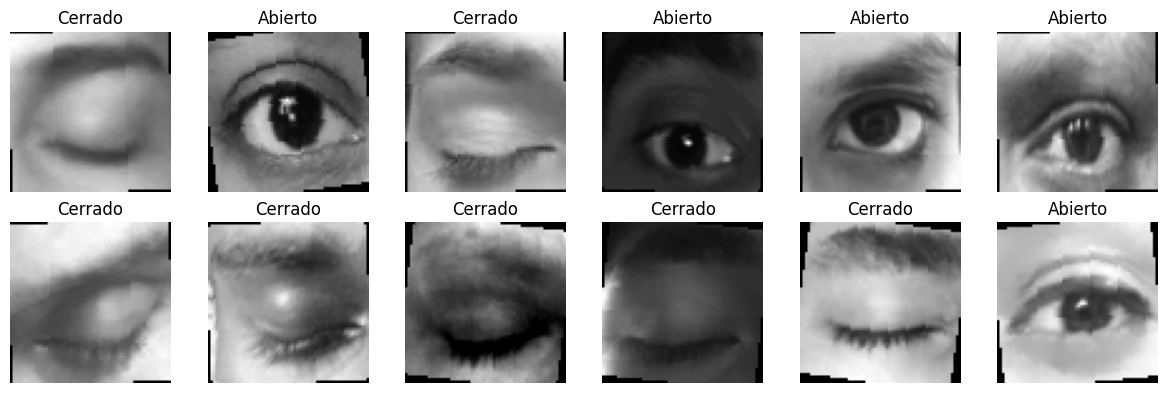

In [3]:
# ============ CELDA 3: Split train/val/test (70/15/15) ============
n = len(keep)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()
idx_train = [keep[i] for i in perm[:n_train]]
idx_val   = [keep[i] for i in perm[n_train:n_train+n_val]]
idx_test  = [keep[i] for i in perm[n_train+n_val:]]

train_ds = EyesDataset(full_ds, idx_train, train_tf)
val_ds   = EyesDataset(full_ds, idx_val,   eval_tf)
test_ds  = EyesDataset(full_ds, idx_test,  eval_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Visualizar algunas muestras
xb, yb = next(iter(train_dl))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, lbl in zip(axes.flat, xb, yb):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASSES[lbl])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# ============ CELDA 4: Modelo CNN binario ============
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 64->32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), # 32->16
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 16->8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = EyeCNN().to(DEVICE)
print(model)
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

EyeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p

In [5]:
# ============ CELDA 5: Entrenamiento ============
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

def evaluate(dl):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * y.size(0)
    train_loss = running / len(train_ds)
    val_loss, val_acc = evaluate(val_dl)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "eye_cnn_best.pth")

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

print(f"\nMejor accuracy validación: {best_acc:.4f} (guardado en eye_cnn_best.pth)")

Epoch 01/15 | train_loss=0.8656 | val_loss=0.4811 | val_acc=0.7972
Epoch 02/15 | train_loss=0.2140 | val_loss=0.3155 | val_acc=0.8710
Epoch 03/15 | train_loss=0.1466 | val_loss=0.1201 | val_acc=0.9585
Epoch 04/15 | train_loss=0.1163 | val_loss=0.0854 | val_acc=0.9724
Epoch 05/15 | train_loss=0.0839 | val_loss=0.0592 | val_acc=0.9862
Epoch 06/15 | train_loss=0.0554 | val_loss=0.0556 | val_acc=0.9770
Epoch 07/15 | train_loss=0.0583 | val_loss=0.0687 | val_acc=0.9724
Epoch 08/15 | train_loss=0.0555 | val_loss=0.0385 | val_acc=0.9816
Epoch 09/15 | train_loss=0.0330 | val_loss=0.0368 | val_acc=0.9862
Epoch 10/15 | train_loss=0.0376 | val_loss=0.0479 | val_acc=0.9724
Epoch 11/15 | train_loss=0.0228 | val_loss=0.0291 | val_acc=0.9908
Epoch 12/15 | train_loss=0.0230 | val_loss=0.0478 | val_acc=0.9862
Epoch 13/15 | train_loss=0.0201 | val_loss=0.0352 | val_acc=0.9908
Epoch 14/15 | train_loss=0.0207 | val_loss=0.0371 | val_acc=0.9908
Epoch 15/15 | train_loss=0.0137 | val_loss=0.0311 | val_acc=0.

C:\Users\aaron\AppData\Local\Temp\ipykernel_4624\487181005.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("eye_cnn_best.pth", map_locat

Test accuracy: 0.9954


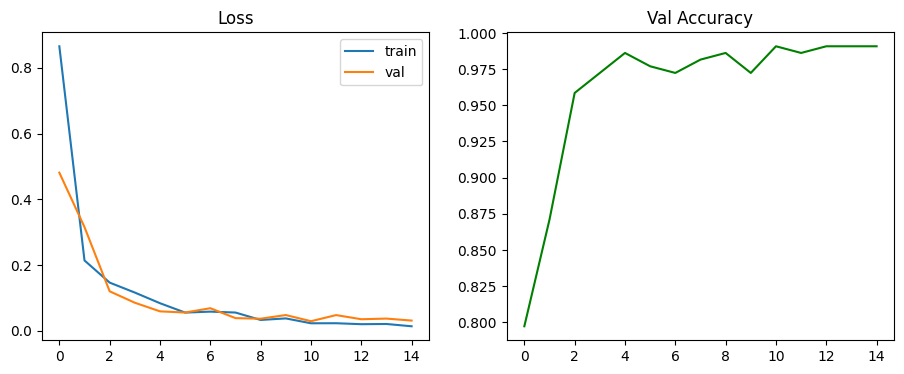

Matriz de confusión (filas=real, cols=pred) [Cerrado, Abierto]:
[[121   0]
 [  1  97]]


In [6]:
# ============ CELDA 6: Evaluación en test + curvas ============
model.load_state_dict(torch.load("eye_cnn_best.pth", map_location=DEVICE))
test_loss, test_acc = evaluate(test_dl)
print(f"Test accuracy: {test_acc:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(history["train_loss"], label="train")
a1.plot(history["val_loss"], label="val")
a1.set_title("Loss"); a1.legend()
a2.plot(history["val_acc"], color="green")
a2.set_title("Val Accuracy")
plt.show()

# Matriz de confusión simple
from collections import Counter
model.eval()
cm = np.zeros((2, 2), dtype=int)
with torch.no_grad():
    for x, y in test_dl:
        pred = model(x.to(DEVICE)).argmax(1).cpu()
        for t, p in zip(y, pred):
            cm[t, p] += 1
print("Matriz de confusión (filas=real, cols=pred) [Cerrado, Abierto]:")
print(cm)

## Detección en tiempo real

**Cómo funciona la "segmentación":** MediaPipe Face Mesh detecta 468 landmarks faciales. Usamos los landmarks del contorno de cada ojo para recortar la región ocular, y esa imagen recortada se pasa a la CNN. Esto reemplaza entrenar un modelo de segmentación dedicado — es más rápido, más robusto y es el estándar en este tipo de sistemas.

**Lógica de alarma:** si ambos ojos se clasifican como *Cerrado* de forma continua durante 5 segundos, suena la alarma (por ahora `winsound` en Windows; luego lo reemplazamos por la señal al ESP32).

Presiona **Q** sobre la ventana de video para salir.

In [8]:
# ============ CELDA 7: Detección en tiempo real con webcam ============
import mediapipe as mp
import winsound  # alarma local en Windows (luego: señal al ESP32)

# Landmarks de MediaPipe para contorno de ojos
LEFT_EYE  = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

UMBRAL_SEGUNDOS = 5.0   # tiempo de ojos cerrados para disparar alarma

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    max_num_faces=1, refine_landmarks=True,
    min_detection_confidence=0.5, min_tracking_confidence=0.5
)

infer_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

def crop_eye(frame, landmarks, eye_idx, w, h, margin=0.6):
    xs = [landmarks[i].x * w for i in eye_idx]
    ys = [landmarks[i].y * h for i in eye_idx]
    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)
    # margen alrededor del ojo
    mx = (x2 - x1) * margin
    my = (y2 - y1) * margin * 1.5
    x1, x2 = int(max(0, x1 - mx)), int(min(w, x2 + mx))
    y1, y2 = int(max(0, y1 - my)), int(min(h, y2 + my))
    if x2 - x1 < 10 or y2 - y1 < 10:
        return None, None
    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)

UMBRAL_ABIERTO = 0.80   # para decir "Abierto" hay que estar 75%+ seguro; si no, es "Cerrado"

@torch.no_grad()
def predict_eye(crop_bgr):
    x = infer_tf(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
    out = model(x)
    prob = torch.softmax(out, dim=1)[0]
    p_abierto = prob[1].item()   # probabilidad de "Abierto"
    # Solo lo declaramos Abierto si supera el umbral; ante la duda -> Cerrado
    pred = 1 if p_abierto >= UMBRAL_ABIERTO else 0
    conf = p_abierto if pred == 1 else (1 - p_abierto)
    return pred, conf

model.eval()
cap = cv2.VideoCapture(0)
closed_since = None
alarma_activa = False

while True:
    ok, frame = cap.read()
    if not ok:
        break
    h, w = frame.shape[:2]
    results = face_mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    estado = "SIN ROSTRO"
    color = (200, 200, 200)

    if results.multi_face_landmarks:
        lms = results.multi_face_landmarks[0].landmark
        preds = []
        for eye_idx in (LEFT_EYE, RIGHT_EYE):
            crop, box = crop_eye(frame, lms, eye_idx, w, h)
            if crop is None:
                continue
            pred, conf = predict_eye(crop)
            preds.append(pred)
            x1, y1, x2, y2 = box
            c = (0, 0, 255) if pred == 0 else (0, 255, 0)
            cv2.rectangle(frame, (x1, y1), (x2, y2), c, 2)
            cv2.putText(frame, f"{CLASSES[pred]} {conf:.2f}", (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1)

        if preds and all(p == 0 for p in preds):      # ambos ojos cerrados
            if closed_since is None:
                closed_since = time.time()
            elapsed = time.time() - closed_since
            estado = f"OJOS CERRADOS {elapsed:.1f}s"
            color = (0, 0, 255)
            if elapsed >= UMBRAL_SEGUNDOS:
                estado = "!!! ALARMA: SOMNOLENCIA !!!"
                if not alarma_activa:
                    alarma_activa = True
                winsound.Beep(1500, 200)   # aquí luego: enviar señal al ESP32
        else:
            closed_since = None
            alarma_activa = False
            if preds:
                estado = "OJOS ABIERTOS"
                color = (0, 255, 0)

    cv2.putText(frame, estado, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.imshow("Deteccion de Somnolencia - Q para salir", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
face_mesh.close()
print("Finalizado")

Finalizado


---
# Conversión a TinyML para ESP32-CAM

Ruta completa: **PyTorch → ONNX → TensorFlow → TFLite (INT8) → `model.h`**

El `model.h` final es un array de C que se compila dentro del sketch del ESP32-CAM y queda grabado en su memoria Flash.

### Instalar dependencias (una sola vez)
```
pip install onnx onnx-tf tensorflow==2.15.0
```
> Nota: `onnx-tf` puede dar conflictos de versión con TensorFlow. Si falla, abajo te dejo una **ruta alternativa más estable** usando `ai-edge-torch` o `nobuco`.

⚠️ **Aviso de tamaño:** tu `EyeCNN` tiene ~2.1M parámetros (la capa `Linear(8192, 256)` se lleva casi todo). Cuantizado pesará ~2 MB, que es **demasiado** para el tensor arena del ESP32-CAM. Estas celdas te sirven para validar el pipeline completo; en la siguiente etapa reduciremos la arquitectura (capa densa más chica o `GlobalAveragePooling`) para que quepa.

In [2]:
import torch
import torch.nn as nn

DEVICE = torch.device("cpu")   # la conversión no necesita GPU
IMG_SIZE = 64
print("Listo para conversión, IMG_SIZE =", IMG_SIZE)

Listo para conversión, IMG_SIZE = 64


In [3]:
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

print("EyeCNN definida ✓")

EyeCNN definida ✓


In [4]:
model = EyeCNN().to(DEVICE)
model.load_state_dict(torch.load("eye_cnn_best.pth", map_location=DEVICE))
model.eval()
print("Modelo cargado ✓")

Modelo cargado ✓


In [6]:
%pip install onnxscript

  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/714.8 kB ? eta -:--:--
   ---------------------------------------- 714.8/714.8 kB 5.7 MB/s  0:00:00
Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl (210 kB)

  Attempting uninstall: ml_dtypes

    Found existing installation: ml-dtypes 0.2.0

    Uninstalling ml-dtypes-0.2.0:

      Successfully uninstalled ml-dtypes-0.2.0

   ---------------------------------------- 0/3 [ml_dtypes]
   ------------- -------------------------- 1/3 [onnx_ir]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]
   -------------------------- ------------- 2/3 [onnxscript]

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.


In [7]:
model.eval()
dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
ONNX_PATH = "eye_model.onnx"

torch.onnx.export(
    model, dummy_input, ONNX_PATH,
    export_params=True, opset_version=13, do_constant_folding=True,
    input_names=["input"], output_names=["output"], dynamic_axes=None,
)
print(f"Exportado a {ONNX_PATH}")

try:
    import onnx
    onnx.checker.check_model(onnx.load(ONNX_PATH))
    print("ONNX válido ✓")
except Exception as e:
    print("Aviso al verificar ONNX:", e)

W0623 22:21:33.645000 14844 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EyeCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EyeCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\aaron\anaconda3\envs\conversion\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\aaron\anaconda3\envs\conversion\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aaron\anaconda3\envs\conversion\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "C:\Users\aaron\anaconda3\envs\con

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exportado a eye_model.onnx
ONNX válido ✓


In [8]:
# ============ CELDA 8: PyTorch -> ONNX ============
import torch

# Asegúrate de tener el modelo entrenado cargado. Si reiniciaste el kernel:
#   model = EyeCNN().to(DEVICE)
#   model.load_state_dict(torch.load("eye_cnn_best.pth", map_location=DEVICE))

model.eval()

# Entrada dummy con la forma exacta que espera el modelo: (batch, canales, alto, ancho)
# 1 canal (grayscale), IMG_SIZE x IMG_SIZE
dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

ONNX_PATH = "eye_model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes=None,   # tamaño fijo: mejor para microcontroladores
)

print(f"Exportado a {ONNX_PATH}")

# Verificación opcional del grafo ONNX
try:
    import onnx
    onnx_model = onnx.load(ONNX_PATH)
    onnx.checker.check_model(onnx_model)
    print("ONNX válido ✓")
except Exception as e:
    print("Aviso al verificar ONNX:", e)

W0623 22:21:53.733000 14844 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EyeCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EyeCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\aaron\anaconda3\envs\conversion\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\aaron\anaconda3\envs\conversion\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aaron\anaconda3\envs\conversion\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "C:\Users\aaron\anaconda3\envs\con

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exportado a eye_model.onnx
ONNX válido ✓


In [9]:
# ============ CELDA 9: ONNX -> TensorFlow (SavedModel) ============
# onnx-tf convierte el grafo ONNX a un SavedModel de TensorFlow.
# OJO: PyTorch usa formato NCHW (canal primero) y TF usa NHWC (canal último).
# onnx-tf maneja la conversión, pero lo tendremos en cuenta al preparar el TFLite.

from onnx_tf.backend import prepare
import onnx

TF_MODEL_DIR = "eye_model_tf"

onnx_model = onnx.load("eye_model.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph(TF_MODEL_DIR)

print(f"SavedModel de TensorFlow guardado en: {TF_MODEL_DIR}")

ImportError: cannot import name 'mapping' from 'onnx' (C:\Users\aaron\anaconda3\envs\conversion\Lib\site-packages\onnx\__init__.py)

In [ ]:
# ============ CELDA 10: Dataset representativo para cuantización INT8 ============
# La cuantización INT8 necesita ver datos reales para calibrar los rangos de cada capa.
# Usamos un puñado de imágenes del set de validación/entrenamiento.

import numpy as np

N_CALIB = 200   # número de muestras de calibración (100-300 es suficiente)

# Tomamos imágenes del dataset ya cargado (val_ds o train_ds del notebook)
calib_samples = []
src_ds = val_ds if 'val_ds' in dir() else train_ds
for i in range(min(N_CALIB, len(src_ds))):
    x, _ = src_ds[i]                      # x: tensor (1, H, W) en rango normalizado
    arr = x.numpy().astype(np.float32)    # (1, H, W)  -> canal primero (PyTorch)
    # TF/TFLite espera NHWC: (H, W, 1)
    arr = np.transpose(arr, (1, 2, 0))    # (H, W, 1)
    calib_samples.append(arr)

calib_samples = np.array(calib_samples, dtype=np.float32)
print("Forma del set de calibración (NHWC):", calib_samples.shape)

def representative_dataset():
    for i in range(len(calib_samples)):
        # cada yield es un batch de 1
        yield [calib_samples[i:i+1]]

In [ ]:
# ============ CELDA 11: TensorFlow -> TFLite con cuantización INT8 completa ============
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("eye_model_tf")

# Cuantización entera completa (todo INT8, ideal para TFLite Micro en ESP32)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8    # entrada en INT8
converter.inference_output_type = tf.int8   # salida en INT8

tflite_model = converter.convert()

TFLITE_PATH = "eye_model_int8.tflite"
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"Modelo TFLite INT8 guardado: {TFLITE_PATH}")
print(f"Tamaño: {size_kb:.1f} KB")
if size_kb > 500:
    print("⚠️  >500 KB: probablemente NO entre en el ESP32-CAM. Hay que reducir la arquitectura.")
else:
    print("✓ Tamaño razonable para ESP32-CAM (verifica también el tensor arena al correr).")

In [ ]:
# ============ CELDA 12: Verificar que el TFLite funciona (sanity check) ============
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(model_path="eye_model_int8.tflite")
interpreter.allocate_tensors()

inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]
print("Input :", inp["shape"], inp["dtype"])
print("Output:", out["shape"], out["dtype"])
print("Escala/zero-point entrada:", inp["quantization"])

# Probamos con una imagen de calibración
sample = calib_samples[0:1]   # (1, H, W, 1) float32 normalizado

# Hay que cuantizar la entrada a INT8 usando la escala del modelo
in_scale, in_zp = inp["quantization"]
sample_int8 = (sample / in_scale + in_zp).astype(np.int8)

interpreter.set_tensor(inp["index"], sample_int8)
interpreter.invoke()
pred = interpreter.get_tensor(out["index"])

# Decuantizar la salida
out_scale, out_zp = out["quantization"]
pred_float = (pred.astype(np.float32) - out_zp) * out_scale
clase = int(np.argmax(pred_float))
print("Logits decuantizados:", pred_float)
print("Clase predicha:", CLASSES[clase], "(0=Cerrado, 1=Abierto)")

In [ ]:
# ============ CELDA 13: TFLite -> model.h (array de C para el ESP32) ============
# Convierte el .tflite en un array de bytes en C que se compila dentro del sketch.
# Equivale al comando 'xxd -i' de Linux, pero en Python multiplataforma (Windows OK).

def tflite_to_header(tflite_path, header_path, var_name="eye_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()

    lines = []
    lines.append("// Modelo generado automáticamente desde eye_model_int8.tflite")
    lines.append("// Clases: 0 = Cerrado, 1 = Abierto")
    lines.append("#ifndef EYE_MODEL_H")
    lines.append("#define EYE_MODEL_H")
    lines.append("")
    lines.append(f"const unsigned int {var_name}_len = {len(data)};")
    lines.append(f"alignas(8) const unsigned char {var_name}[] = {{")

    # 12 bytes por línea, en hexadecimal
    for i in range(0, len(data), 12):
        chunk = data[i:i+12]
        hexs = ", ".join(f"0x{b:02x}" for b in chunk)
        lines.append(f"  {hexs},")

    lines.append("};")
    lines.append("")
    lines.append("#endif  // EYE_MODEL_H")

    with open(header_path, "w") as f:
        f.write("\n".join(lines))

    return len(data)

n = tflite_to_header("eye_model_int8.tflite", "model.h", var_name="eye_model")
print(f"model.h generado ✓  ({n} bytes, {n/1024:.1f} KB)")
print("Este archivo se copia a la carpeta del sketch del ESP32-CAM y se incluye con:")
print('   #include "model.h"')

### Si `onnx-tf` te da problemas (ruta alternativa)

`onnx-tf` es notoriamente frágil con versiones recientes de TensorFlow. Si las celdas 9-11 fallan, dos alternativas más estables:

**Opción 1 — `ai-edge-torch` (de Google, PyTorch → TFLite directo):**
```python
pip install ai-edge-torch
```
```python
import ai_edge_torch
sample = (torch.randn(1, 1, IMG_SIZE, IMG_SIZE),)
edge_model = ai_edge_torch.convert(model.eval().cpu(), sample)
edge_model.export("eye_model.tflite")
```
Esto salta ONNX y TensorFlow por completo. Luego aplicas cuantización y la Celda 13 igual.

**Opción 2 — reentrenar directo en Keras** (lo más robusto para TinyML). Como tu dataset ya está organizado, replicar la CNN en Keras es directo y evita todo el problema de conversión. Esta es la ruta que yo recomendaría para la versión final del proyecto.

Dime cuál prefieres y te armo esas celdas.

## Próximos pasos (integración ESP32)

1. **ESP32 con buzzer:** sketch en Arduino IDE que escuche por WiFi (HTTP o MQTT) o por puerto serial.
2. **En la celda 7**, reemplazar `winsound.Beep(...)` por:
   - Serial: `serial.Serial('COM3', 115200).write(b'1')`
   - WiFi: `requests.get('http://<IP_ESP32>/alarma')`
3. El ESP32 activa el buzzer con `digitalWrite(PIN_BUZZER, HIGH)` al recibir la señal.

Cuando tengas el ESP32 a la mano, lo conectamos.